### FINETUNING FOR CLASSIFICATION

In [ ]:
import urllib.request
import ssl
import zipfile
import os
from pathlib import Path

# UC Irvine ML Repository (SMS Spam Collection) 
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f'{data_file_path} already exists. Skipping download and extraction.')
        return

    # Create an unverified SSL context
    ssl_context = ssl._create_unverified_context()

    # Downloading the file
    with urllib.request.urlopen(url, context=ssl_context) as response:
        with open(zip_path, 'wb') as out_file:
            out_file.write(response.read())
    
    # Unzipping the file
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_path)
    
    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f'File downloaded and saved as: {data_file_path}')

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

File downloaded and saved as: sms_spam_collection/SMSSpamCollection.tsv


After executing the preceding code, the dataset is saved as a tab-separated text file, SMSSpamCollection.tsv, in the sms_spam_collection folder.

We can load it into a pandas DataFrame as follows:

In [9]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


When we check the class distribution, we see that the data contains "ham" (i.e., "not spam") much more frequently than "spam"

Double-click to edit:

In [10]:
print(df['Label'].value_counts())
# ham represents text that is considered "NOT SPAM"
# spam represents text that is considered "SPAM"

Label
ham     4825
spam     747
Name: count, dtype: int64


For simplicity, and because we prefer a small dataset for educational purposes anyway (it will make it possible to finetune the LLM faster), we subsample (undersample) the dataset so that it contains 747 instances from each class

In [11]:
def create_balanced_dataset(df):

    # Count the instances of 'spam'
    num_spam = df[df['Label'] == 'spam'].shape[0]

    # Randomly sample 'ham' instances to match the number of 'spam' instances
    ham_subset = df[df['Label'] == 'ham'].sample(num_spam, random_state=123)

    # Combine the ham 'subset' with 'spam'
    balanced_df = pd.concat([ham_subset, df[df['Label'] == 'spam']])

    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df['Label'].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


After executing the previous code to balance the dataset, we can see that we now have equal amounts of spam and non-spam messages:

Next, we can convert the "string" class labels "ham" and "spam" into integer class labels 0 and 1, respectively:

In [12]:
balanced_df['Label'] = balanced_df['Label'].map({"ham": 0, "spam": 1})
balanced_df

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


This process is similar to converting text into token IDs.

However, instead of using the GPT vocabulary, which consists of more than 50,000 words, we are dealing with just two token IDs: 0 and 1.

We create a random_split function to split the dataset into three parts: 70% for training, 10% for validation, and 20% for testing.

(These ratios are common in machine learning to train, adjust, and evaluate models.)

In [13]:
def random_split(df, train_frac, val_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    val_end = train_end + int(len(df) * val_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    val_df = df[train_end:val_end]
    test_df = df[val_end:]

    return train_df, val_df, test_df

train_df, val_df, test_df = random_split(balanced_df, 0.70, 0.10)
# Test size is implied to be 0.2 as the remainder of (1-0.70-0.10)

In [18]:
print(len(train_df))
print(len(val_df))
print(len(test_df))

assert (len(train_df) + len(val_df) + len(test_df)) == 1494

1045
149
300


Additionally, we can save the dataset as CSV (comma-separated value) files, which we can reuse later:

In [17]:
save_dir = 'data_splits'
os.makedirs(save_dir, exist_ok=True)

train_df.to_csv(f"{save_dir}/train.csv", index=False)
val_df.to_csv(f"{save_dir}/validation.csv", index=False)
test_df.to_csv(f"{save_dir}/test.csv", index=False)

### CREATING DATALOADERS

Previously, we utilized a sliding window technique to generate uniformly sized text chunks, which were then grouped into batches for more efficient model training. Each chunk functioned as an individual training instance

In the case of email spam classification, have two primary options:

(1) Truncate all messages to the length of the shortest message in the dataset or batch.

(2) Pad all messages to the length of the longest message in the dataset or batch.

Option 1 is computationally cheaper, but it may result in significant information loss if shorter messages are much smaller than the average or longest messages, potentially reducing model performance.

So, we opt for the second option, which preserves the entire content of all messages.

To implement option 2, where all messages are padded to the length of the longest message in the dataset, we add padding tokens to all shorter messages.

For this purpose, we use "<|endoftext|>" as a padding token, as discussed in chapter 2.

However, instead of appending the string "<|endoftext|>" to each of the text messages directly, we can add the token ID corresponding to "<|endoftext|>" to the encoded text

First, we need to implement a PyTorch Dataset, which will specify how the data is loaded and processed, before we move onto instantiating the data loaders

For this purpose, we define the SpamDataset class.

This SpamDataset class handles several key tasks: it identifies the longest sequence in the training dataset, encodes the text messages, and ensures that all other sequences are padded with a padding token to match the length of the longest sequence.

In [26]:
import torch
from torch.utils.data import Dataset


class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pre-tokenize texts
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncate sequences if they are longer than max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Pad sequences to the longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            max_length = max(max_length, len(encoded_text))
        return max_length

#### STEPS:
Step 1: Pre-tokenize texts

Step 2: Truncate sequences if they are longer than max_length

Step 3: Pad sequences to the longest sequence

The SpamDataset class loads data from the CSV files we created earlier, tokenizes the text using the GPT-2 tokenizer from tiktoken and allows us to pad or truncate the sequences to a uniform length determined by either the longest sequence or a predefined maximum length.

This ensures each input tensor is of the same size, which is necessary to create the batches in the training data loader we implement next:

In [27]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

In [29]:
train_dataset = SpamDataset(
    csv_file='data_splits/train.csv',
    max_length=None,
    tokenizer=tokenizer
)

print(f'train_dataset max length: {train_dataset.max_length}')

train_dataset max length: 120


The code outputs 120, showing that the longest sequence contains no more than 120 tokens, a common length for text messages.

It's worth noting that the model can handle sequences of up to 1,024 tokens, given its context length limit.

If your dataset includes longer texts, you can pass max_length=1024 when creating the training dataset in the preceding code to ensure that the data does not exceed the model's supported input (context) length.

Next, we pad the validation and test sets to match the length of the longest training sequence.

It's important to note that any validation and test set samples exceeding the length of the longest training example are truncated using encoded_text[:self.max_length] in the SpamDataset code we defined earlier.

This truncation is optional; you could also set max_length=None for both validation and test sets, provided there are no sequences exceeding 1,024 tokens in these sets

In [ ]:
val_dataset = SpamDataset(
    csv_file='data_splits/validation.csv',
    tokenizer=tokenizer,
    max_length=train_dataset.max_length
)

test_dataset = SpamDataset(
    csv_file='data_splits/test.csv',
    tokenizer=tokenizer,
    max_length=train_dataset.max_length
)
print(val_dataset.max_length)
print(test_dataset.max_length)

71
92


If we leave the max_length of the validation and testing datasets as None, we would find that the largest token length texts within these datasets respectively are 71, and 92. 

We will stick with the train_dataset's max_length of 120, but do note that whether not we set max_length to be dynamic for each dataset, or set it to max_length of train_dataset, it doesn't matter.

Using the datasets as inputs, we can instantiate the data loaders similarly to what we did earlier.

However, in this case, the targets represent class labels rather than the next tokens in the text.

For instance, choosing a batch size of 8, each batch will consist of 8 training examples of length 120 and the corresponding class label of each example.

In [36]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True # If last batch has smaller data samples, we just drop it (< 8 in this case)
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False
)

To ensure that the data loaders are working and are indeed returning batches of the expected size, we iterate over the training loader and then print the tensor dimensions of the last batch:

In [37]:
print("Train Loader:")
for input_batch, target_batch in train_loader:
    pass

print(f"Input batch dimensions: {input_batch.shape}")
print(f"Target batch dimensions: {target_batch.shape}")

Train Loader:
Input batch dimensions: torch.Size([8, 120])
Target batch dimensions: torch.Size([8])


From above, we can see that the input batches consist of 8 training examples with 120 tokens each, as expected

The label tensor stores the class labels corresponding to the 8 training examples

Finally, to get an idea of the dataset size, we can print out the total number of batches in each dataset

In [33]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
37 test batches


We have completeted the data preparation phase, and can move onto finetuning next.

### INITIALIZING A MODEL WITH PRETRAINED WEIGHTS

In this section, we prepare the model we will use for the classification-finetuning to identify spam messages.

We start with initializing the pretrained model we worked with in the previous chapter

In [40]:
CHOSEN_MODEL = 'gpt2-small (124M)'
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOSEN_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)


#### Redefine the load_weights_into_gpt method from an earlier notebook:

In [46]:
import numpy as np

def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    # Weight tying which is why we assign out_head to token_embeddings
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


Next, we import the download_and_load_gpt function from the gpt_download3.py file we downloaded earlier.

Furthermore, we also reuse the GPTModel class and load_weights_into_gpt function from chapter 5 to load the downloaded weights into the GPT model:

In [47]:
model_size = CHOSEN_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

from gpt_download3 import download_and_load_gpt2
from gpt_model import GPTModel

settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

To ensure that the model was loaded correclty, we can double-check that it generates coherent text

##### First, we will need to redefine the generate_text_simple method:

In [49]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the currnet context

    ### Input batch: 
    ### tensor([[6109, 3626, 6100,  345],
    ###    [6109, 1110, 6622,  257]])

    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # i.e. If LLM supports only 5 tokens, and the context size is 10,
        # then only the last 5 tokens are used as context
        idx_cond = idx[:,-context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)  # (batch, n_tokens, vocab_size)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) -> (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probs = torch.softmax(logits, dim=-1)  # (batch, vocab_size

        # Get the idx of the vocab entry with the highest probability value
        next_idx = torch.argmax(probs, dim=-1, keepdim=True)  # (batch, 1)

        # Append the predicted index to the running sequence
        idx = torch.cat((idx, next_idx), dim=-1)  # (batch, n_tokens+1)

    return idx

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

In [51]:
test_text = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(test_text, tokenizer),
    max_new_tokens=25,
    context_size=BASE_CONFIG['context_length']
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work.

The second step is to understand the


Before we move onto finetuning the model as a spam classifier, let's see if the model can maybe already classify spam messages by prompting it with instructions.

Essentially, let's see if spam classifying is an emergent property

In [52]:
test_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(test_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


As we can see from the output, it's apparent that the model struggles with following instructions.

This is as expected though because the model has only undergone pretraining, and thus, is only capable of predicting the next token.

It lacks instruction finetuning, which will be explored in the coming cells.

Next section prepares the model for classification-finetuning

### ADDING A CLASSIFICATION HEAD

Here, we will modify the pretrained LLM to prepare it for classification-finetuning.

In order to do this, we have to replace the output layer, which maps representation to a vocabulary of 50,257 tokens, with a smaller output layer that maps the two classes:

0 is ('not spam') and 1 is ('spam')

We COULD technically use a single output node since we are dealing with a binary classification task, BUT

This would require modifying the loss function

Therefore, we will choose a more general approach where the number of output nodes matches the number of classes

For example, for a 3-class problem, such as political candidates as "Republican", "Democrat", and "Independent", we could use three output nodes, and so forth

Before moving onto attempting to construct the modified architecture, let us print the model architecture via print(model) as shown below:

In [54]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

Above, we can see the GPT architecture neatly laid out

As we know from before, the GPTModel consists of embedding layers followed by 12 identical transformer blocks (only the last block is shown for brevity), followed by a final LayerNorm and the output layer, out_head

Next, we will replace the out_head with a new output layer, that we will also finetune

To get the model ready for classification-finetuning, we first freeze the model, meaning that we make all layers non-trainable:

In [55]:
for param in model.parameters():
    param.requires_grad = False

Then, replace the output layer (model.out_head), which originally maps the layer inputs to 50,257 dimensions (vocab_size)

In [56]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG['emb_dim'], out_features=num_classes)

Note that in the preceding code, we use BASE_CONFIG["emb_dim"], which is equal to 768 in the "gpt2-small (124M)" model, to keep the code below more general.

This means we can also use the same code to work with the larger GPT-2 model variants.

This new model.out_head output layer has its requires_grad attribute set to True by default, which means that it's the only layer in the model that will be updated during training. (This is our main task, to finetune the output_head)

Additionally, configure the last transformer block and the final LayerNorm module, which connects this block to the output layer, to be trainable. This way, we can still shape/tune certain parameters that come before the classification task, without having to re-train the entire model

In [57]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

Even though we added a new output layer and marked certain layers as trainable or nontrainable, we can still use this model in a similar way to previous chapters.

For instance, we can feed it an example text identical to how we have done it in earlier chapters. For example, consider the following example text:

In [60]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print(f'Inputs: {inputs}')
print(f"Inputs dimensions: {inputs.shape}") # shape: (batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


Now, pass the encoded token IDs to the model as per usual:

In [61]:
with torch.no_grad():
    outputs = model(inputs)

print(f'Outputs: \n {outputs}')
print(f'Outputs dimensions: {outputs.shape}') # shape: (batch_size, num_tokens, num_classes)

Outputs: 
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


In earlier chapters, a similar input would have produced an output tensor of [1, 4, 50257], where 50,257 represents the vocabulary size.

As in previous chapters, the number of output rows corresponds to the number of input tokens (in this case, 4).

However, each output's embedding dimension (the number of columns) is now reduced to 2 instead of 50,257 since we replaced the output layer of the model.

Remember that we are interested in finetuning this model so that it returns a class label that indicates whether a model input is spam or not spam.

To achieve this, we don't need to finetune all 4 output rows but can focus on a single output token.

In particular, we will focus on the last row corresponding to the last output token

To extract the last output token from the output tensor, we can perform something like this:

In [ ]:
print(f'Last output token: {outputs[:,-1,:]}')
# num_tokens is the second dimension, and we want to get the LAST token, hence the -1
# For all batches, get the last TOKEN's num_classes. In this case, num_classes=2


Last output token: tensor([[-3.5983,  3.9902]])


Having modified the model, the next section will detail the process of transforming the last token into class label predictions and calculate the model's initial prediction accuracy.

Following this, we will finetune the model for the spam classification task in the subsequent section.

### CALCULATING THE CLASSIFICATION LOSS AND ACCURACY

We still need to implement the model evaluation functions used during finetuning before we can move onto the finetuning task itself

In the previous parts, we computed the token ID of the next token generated by the LLM by converting the 50,257 outputs into probabilities via the softmax function and then returning the position of the highest probability via the argmax function.

In this part, we take the same approach to calculate whether the model outputs a "spam" or "not spam" prediction for a given input, with the only difference being that we work with 2-dimensional instead of 50,257-dimensional outputs.

Consider the last token output from previous section:

In [63]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


We can get the class label through the following code:

In [64]:
probs = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probs)
print("Class label:", label.item())

Class label: 1


In this case, the code returns 1, meaning that the model predicts that the input text is 'spam'

Using the softmax function here is optional because the largest outputs directly correspond to the highest probability socres.

So, we can simplify the code as follows below using argmax:

In [65]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


This concept can be used to compute the so-called classification accuracy, which measures the percentage of correct predictions across a dataset.

To determine the classification accuracy, we apply the argmax-based prediction code to all examples in the dataset and calculate the proportion of correct predictions by defining a calc_accuracy_loader function:

In [66]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

Now, we can use this function to determine the classification accuracies accross various datasets estimated from 10 batches for efficiency

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# AM COMMENTING OUT FOR REPRODUCABILITY SAKE
# if torch.cuda.is_available():
#    device = torch.device("cuda")
# elif torch.backends.mps.is_available():
#    device = torch.device("mps")
# else:
#    device = torch.device("cpu")
# print(f"Running on {device} device.")

model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123) # For reproducibility due to the shuffling in the training data loader

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")


Running on mps device.
Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


As we can see from above, the prediction accuracties are near a random prediction, which would be 50% in this case

To improve the model prediction accuracies, we will need to finetune

Classification accuracy is not a differentiable function, so we use cross entropy loss as a proxy to maximize accuracy.

This is the same cross entropy loss discussed earlier.

Accordingly, the calc_loss_batch function remains the same as in earlier, with one adjustment: we focus on optimizing only the last token, model(input_batch)[:, -1, :], rather than all tokens, model(input_batch):

In [82]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss


We use the calc_loss_batch function to compute the loss for a single batch obtained from the previously defined data loaders. To calculate the loss for all batches in a data loader, we define the calc_loss_loader function

In [83]:
# Same loss loader as before; same as in chapter 5
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

Similar to calculating the training accuracy, we will now compute the initail loss for each data set:

In [84]:
with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.772
Validation loss: 2.904
Test loss: 2.746


In the next part, we will look at how to implement a training function to finetune the model, which means adjusting the model to minimize the training set loss.

Minimizing the training set loss will help increase the classification accuracy, which is the overall goal

### FINETUNING THE MODEL ON SUPERVISED DATA

In this section, we define and use the training function to finetune the pretrained LLM and improve its spam classification accuracy.

The training loop is the same overall training loop we used earlier, with the only difference being that we calculate the classification accuracy instead of generating a sample text for evaluating the model.

The training function also closely mirrors the train_model_simple function used for pretraining the model earlier.

The only two distinctions are that we now track the number of training examples seen (examples_seen) instead of the number of tokens, and we calculate the accuracy after each epoch instead of printing a sample text:

#### STEPS:

Step 1: Set model to training mode

Step 2: Reset loss gradients from previous batch iteration

Step 3: Calculate loss gradients

Step 4: Update model weights using loss gradients

Step 5: New: track examples instead of tokens

Step 6: Optional evaluation step

Step 7: Calculate accuracy after each epoch

In [74]:
# Same as before, in the GPT Transformer architecture
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [ ]:
# Overall the same as `train_model_simple` in chapter 5
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            examples_seen += input_batch.shape[0] # New: track examples instead of tokens
            global_step += 1

            ## 130 batches: training, eval_freq = 50 --> After 50 batches are processed,
            ## in each epoch, we print the train loss and val loss

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

Next, we can initialize the optimizer, and set the number of training epochs, and initiate the training using the train_classifier_simple function

We can then discuss the choice of the number of training epochs after we have evaluated the results

The training takes about 6 minutes on a M3 MacBook Air laptop computer and less than half a minute on a V100 or A100 GPU"\:"

In [86]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.446, Val loss 2.715
Ep 1 (Step 000050): Train loss 0.624, Val loss 0.653
Ep 1 (Step 000100): Train loss 0.524, Val loss 0.625
Training accuracy: 70.00% | Validation accuracy: 82.50%
Ep 2 (Step 000150): Train loss 0.577, Val loss 0.468
Ep 2 (Step 000200): Train loss 0.422, Val loss 0.571
Ep 2 (Step 000250): Train loss 0.411, Val loss 0.541
Training accuracy: 82.50% | Validation accuracy: 70.00%
Ep 3 (Step 000300): Train loss 0.336, Val loss 0.496
Ep 3 (Step 000350): Train loss 0.347, Val loss 0.456
Training accuracy: 82.50% | Validation accuracy: 75.00%
Ep 4 (Step 000400): Train loss 0.270, Val loss 0.441
Ep 4 (Step 000450): Train loss 0.367, Val loss 0.364
Ep 4 (Step 000500): Train loss 0.287, Val loss 0.361
Training accuracy: 100.00% | Validation accuracy: 90.00%
Ep 5 (Step 000550): Train loss 0.200, Val loss 0.190
Ep 5 (Step 000600): Train loss 0.082, Val loss 0.072
Training accuracy: 97.50% | Validation accuracy: 97.50%
Training completed in 4.60 min

Next, we can use matplotlib to plot the loss function for the training and validation set

In [87]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

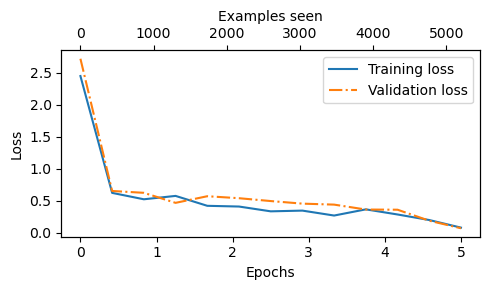

In [88]:
# Plot the graphs by calling the plot_values function
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

From the graph, we can see that based on the sharp downward slope, the model is learning well from the training data, and there is little to no indication of overfitting

In other words, there is no noticable gap between the training and validation set losses

Using the same plot_values function, we can now also plot the classification accuracties, whuch is our main goal in this spam classification problem

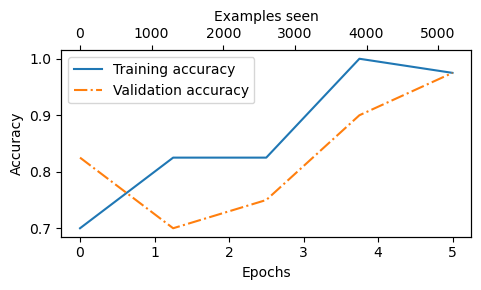

In [89]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

Based on the accuracy plot in figure 6.17, the model achieves a relatively high training and validation accuracy after epochs 4 and 5.

However, it's important to note that we previously set eval_iter=5 when using the train_classifier_simple function, which means our estimations of training and validation performance were based on only 5 batches for efficiency during training.

Now, we will calculate the performance metrics for the training, validation, and test sets across the entire dataset by running the following code, this time without defining the eval_iter value:

In [90]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 96.73%
Validation accuracy: 95.97%
Test accuracy: 95.33%


From above, we can see that the training and test set performances are almost identical

A slighy discrepancy is seen between the training and test set accuracies which suggests minimal overfitting of the trainign data

Typically, the validation set accuracy is somewhat higher than the test set accuracy because the model development often involves tuning hyperparameters to perform well on the validation set, which might not generalize as effectively to the test set. In this case, however, our training accuracy is slightly larger than the validation accuracy, which is fine.

This situation is common, but the gap could potentially be minimized by adjusting the model's settings, such as increasing the dropout rate (drop_rate) or the weight_decay parameter in the optimizer configuration.

### USING THE LLM AS A SPAM CLASSIFIER

After finetuning and evaluating the model in the previous sections, we are now in the final stage of this chapter: using the model to classify spam messages.

Finally, let's use the finetuned GPT-based spam classification model.

The following classify_review function follows data preprocessing steps similar to those we used in the SpamDataset implemented earlier in this chapter.

And then, after processing text into token IDs, the function uses the model to predict an integer class label, similar to what we have implemented earlier, and then returns the corresponding class name:

#### STEPS:

Step 1: Prepare inputs to the model

Step 2: Truncate sequences if they too long

Step 3: Pad sequences to the longest sequence

Step 4: Add batch dimension

Step 5: Model inference without gradient tracking

Step 6: Logits of the last output token

Step 7: Return the classified result


In [ ]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0] 
    # Note: In the book, this was originally written as pos_emb.weight.shape[1] by mistake
    # It didn't break the code but would have caused unnecessary truncation (to 768 instead of 1024)

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]

    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Return the classified result
    return "spam" if predicted_label == 1 else "not spam"

Try the classify_review function on this example text below:

In [107]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


As we can see, the resulting model correctly predicts 'spam'.

In [102]:
# Now try on different inputs. I'll even throw in some numbers to make it look somewhat spammy

text_2 = (
    "I'm going to lob you a $1000 reward for finding my dog"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


Also above, the model makes a correct prediction and returns a "not spam" label.

Finally, let's save the model in case we want to reuse the model later without having to train it again using the torch.save method

In [ ]:
# Save to model checkpoints folder
torch.save(model.state_dict(), "model_checkpoints/review_classifier.pth")


Once we save it, we can loda it through this function below:

In [99]:
model_state_dict = torch.load("model_checkpoints/review_classifier.pth")
model.load_state_dict(model_state_dict)

<All keys matched successfully>

### INSTRUCTION FINETUNING

### STEP 1: PREPARING DATASET:

We will downlaod and format the instruction dataset for instruction finetuning a pretrained LLM in this chapter. The dataset consists of 1100 instruction-response pairs.

The following code implements and executes a function to download this dataset, which is a relatively small file, only 204 KB in size, in JSON format. JSON, or JavaScript Object Notation, mirrors the structure of Python dictionaries, providing a simple structure for data interchange that is both human-readable and machine-friendly.

In [109]:
import json
import os
import urllib
import ssl

def download_and_load_file(file_path, url):
    ssl_context = ssl.create_default_context()
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE

    if not os.path.exists(file_path):
        with urllib.request.urlopen(url, context=ssl_context) as response:
            text_data = response.read().decode('utf8')
        with open(file_path, 'w', encoding='utf-8') as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)
    
    return data

file_path = 'instruction-data.json'

url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


The data list, which we loaded from the JSON file, contains the 1100 entries of the instruction dataset.

We can print one of the data points below to see how the entry is structurd:

In [110]:
print(f'Example entry: \n {data[50]}')

Example entry: 
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [ ]:
print(f'Another example entry: \n {data[1000]}')

Another example entry: 
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


### CONVERING INSTRUCTIONS INTO ALPACA FORMAT

In [112]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text


This format_input function takes a dictionary entry as input and constructs a formatted string.

Now, let's test this on data point data[50], which we printed earlier

In [113]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


Note that the format_input skips the optional ### Input: section if the 'input' field is empty, which we can test out by applying the format_input function to entry data[1000] that we inspected earlier:

In [128]:
model_input = format_input(data[1000])
desired_response = f"\n\n### Response:\n{data[1000]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name three forms of water.

### Response:
The three forms of water are solid (ice), liquid (water), and gas (steam).


### CONVERT INSTRUCTIONS INTO PHI-3 FORMAT

In [125]:
import string

def format_phi_3(entry):
    instruction = entry['instruction'].strip()
    input_entry = entry['input'].strip()
    output_text = entry['output'].strip()

    # Remove trailing punctuation (., ?, !) if present
    if instruction and instruction[-1] in string.punctuation:
        instruction = instruction[:-1]

    # Phi-3 format example:
    formatted = (
        f"<|user|>\n"
        f"{instruction}: {input_entry}\n\n"
        f"<|assistant|>\n"
        f"{output_text}"
    )
    
    return formatted


In [ ]:
model_response = format_phi_3(data[50])

print(model_response)

<|user|>
Identify the correct spelling of the following word: Ocassion

<|assistant|>
The correct spelling is 'Occasion.'


In [127]:
model_response = format_phi_3(data[1000])
print(model_response)

<|user|>
Name three forms of water: 

<|assistant|>
The three forms of water are solid (ice), liquid (water), and gas (steam).


### SPLITTING DATASET INTO TRAIN-TEST-VALIDATION

In [115]:
train_portion = int(len(data) * 0.85) # 85% for training
test_portion = int(len(data) * 0.10)  # 10% for testing
val_portion = len(data) - train_portion - test_portion # Remaining percentage of data

train_data = data[:train_portion]
test_data = data[train_portion:train_portion+test_portion]
val_data = data[train_portion+test_portion:]

In [116]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


Having successfully downloaded and partitioned the dataset, and gained a clear understanding of the dataset prompt formatting, we are now ready for the core implementation of the instruction finetuning process.

### STEP 2: ORGANIZING DATA INTO TRAINING BATCHES

In the previous chapter, the training batches were created automatically by the PyTorch DataLoader class, which employs a default collate function to combine lists of samples into batches.

A collate function is responsible for taking a list of individual data samples and merging them into a single batch that can be processed efficiently by the model during training.

However, the batching process for instruction finetuning in this chapter is a bit more involved and requires us to create our own custom collate function that we will later plug into the DataLoader.

We implement this custom collate function to handle the specific requirements and formatting of our instruction finetuning dataset.

First, we will have to code an InstructionDataset class that applies format_input (Alpaca formatting) from the previous section and pretokenizes all inputs in the dataset, similar to the SpamDataset that was created earlier for Classification Finetuning

In [163]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )
    
    def __getitem__(self, index):
        return self.encoded_texts[index]
    
    def __len__(self):
        return len(self.data)


Similar to the approach in chapter 6, we aim to accelerate training by collecting multiple training examples in a batch, which necessitates padding all inputs to a similar length.

As with the previous chapter, we use the <|endoftext|> token as a padding token.

Instead of appending the <|endoftext|> tokens to the text inputs, we can append its token ID to the pre-tokenized inputs directly.

To remind us which token ID we should use, we can use the tokenizer's .encode method on an <|endoftext|> token:

In [164]:
import tiktoken
tokenizer = tiktoken.get_encoding('gpt2')

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In chapter 6, we padded all examples in a dataset to the same length.

Moving on, here, we adopt a more sophisticated approach by developing a custom collate function that we can pass to the data loader.

This custom collate function pads the training examples in each batch to have the same length, while allowing different batches to have different lengths.

This approach minimizes unnecessary padding by only extending sequences to match the longest one in each batch, not the whole dataset.

We can implement the padding process with a custom collate function as follows:

#### STEPS:

Step 1: Find the longest sequence in the batch

Step 2: Pad and prepare inputs

Step 3: Remove extra padded token added earlier

Step 4: Convert list of inputs to tensor and transfer to target device

In [165]:
def custom_collate_draft_1(batch, pad_token_id=50256, device='cpu'):
    # Find the longest sequence in the batch
    # and increase the max length by +1, which will add one extra
    # padding token below (end-of-text token)
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_list = []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to batch_max_length
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        # Through the padded[:-1], we can remove the extra padded token
        # that has been added via the +1 setting in batch_max_length
        # (The extra padding token will be relevant in later code)

        inputs = torch.tensor(padded[:-1])
        inputs_list.append(inputs)
    
    # Convert the list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_list).to(device)
    return inputs_tensor

The custom_collate_draft_1 we implemented is designed to be integrated into a PyTorch DataLoader, but it can also function as a standalone tool.

Here, we use it independently to test and verify that it operates as intended.

Let's try this on three different inputs that we want to assemble into a batch, where each example gets padded to the same length 

In [166]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


From the output above, we can see that all inputs have been correctly padded to the length of the longest input sample, which in this case is sample 1, containing 5 token IDs

So far, we have just implemented our first custom collate function to create batches from lists of inputs.

However, as learned in previous lessons, we also need to create batches with the target token IDs, corresponding to the batch of input IDs.

These target IDs are crucial because they represent what we want the model to generate and what we need during training to calculate the loss for the weight updates, similar to previous chapters.

### CREATING TARGET TOKEN IDS FOR TRAINING

Similar to the process described for pretraining an LLM, the target token IDs match the input token IDs but are shifted one position to the right.

This setup allows the LLM to learn how to predict the next token in a sequence.

The following updated collate function generates the target token IDs from the input token IDs:

In [167]:
def custom_collate_draft_2(batch, pad_token_id=50256, device='cpu'):
    # Find the longest sequence in the batch
    # and increase the max length by +1, which will add one extra
    # padding token below (end-of-text token)
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_list = []
    target_list = []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to batch_max_length
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        # Through the padded[:-1], we can remove the extra padded token
        # that has been added via the +1 setting in batch_max_length
        # (The extra padding token will be relevant in later code)

        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets
        
        inputs_list.append(inputs)
        target_list.append(targets)
    
    # Convert the list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_list).to(device)
    target_tensor = torch.stack(target_list).to(device)
    return inputs_tensor, target_tensor

Step 1: Truncate the last token for inputs

Step 2: Shift +1 to the right for targets

In [168]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)


tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


The first tensor printed represents the inputs

The second tensor printed represents the targets

In the next step, we assign a -100 placeholder value to all padding tokens.

This special value allows us to exclude these padding tokens from contributing to the training loss calculation, ensuring that only meaningful data influences model learning.

PyTorch's Cross Entropy Loss function has an ignore_index default value set to -100, which means we avoid those tokens in learning, which makes training more efficient, and does not unnecessairly include the unimportant tokens (excessive padding/end-of-text tokens)

FOR REFERENCE:
(class torch.nn.CrossEntropyLoss(weight=None, size_average=None, ignore_index=-100, reduce=None, reduction='mean', label_smoothing=0.0)

In classification fine-tuning, we did not have to worry about this since we only trained the model based on the last output token.)

Note that we retain one end-of-text token, ID 50256, in the target list.

This allows the LLM to learn when to generate an end-of-text token in response to instructions, which we use as an indicator that the generated response is complete.

In the following code, we modify our custom collate function to replace tokens with ID 50256 with -100 in the target lists.

Additionally, we introduce an allowed_max_length parameter to optionally limit the length of the samples.

This adjustment will be useful if you plan to work with your own datasets that exceed the 1024- token context size supported by the GPT-2 model.

The code for this updated collate function is as follows:

In [169]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
        # Find the longest sequence in the batch
    # and increase the max length by +1, which will add one extra
    # padding token below (end-of-text token)
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_list = []
    target_list = []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to batch_max_length
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        # Through the padded[:-1], we can remove the extra padded token
        # that has been added via the +1 setting in batch_max_length
        # (The extra padding token will be relevant in later code)

        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # NEW: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index
        
        # NEW: Optionally, truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
        
        inputs_list.append(inputs)
        target_list.append(targets)
    
    # Convert the list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_list).to(device)
    target_tensor = torch.stack(target_list).to(device)
    return inputs_tensor, target_tensor

Step 1: Replace all but the first padding tokens in targets by ignore_index

Step 2: Optionally truncate to maximum sequence lengthm

Now, we will try the collate function again on the simple test batch that we have created earlier, to check if everything is working accordingly

In [170]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


From above, we can see that the collate function is working as expected, by altering the target list by inserting the token ID -100 for all excess padding tokens

Question: What is the logic behind this adjustment? Let's explore the underlying purpose of this modification.

For demonstration purposes, consider the following simple and self-contained example where each output logit can correspond to a potential token from the model's vocabulary.

Here's how we might calculate the cross entropy loss (introduced in chapter 5) during training when the model predicts a sequence of tokens, similar to what we have done in chapter 5 when pretraining the model, or in chapter 6 when finetuning the model for classification:

In [171]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


Adding an additional token ID will, as we would expect, affect the loss calculation.

In [172]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


Now onto the interesting part, let's see what happens if we replace the third token ID with -100:

In [173]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


Based on this result, we can see that the resulting loss on these 3 training examples is identical to the loss we calculated from the 2 training examples earlier.

In other words, the cross entropy loss function ignored the third entry in the targets_3 vector, the token ID corresponding to -100.

(Interestingly, we can try to replace the -100 value with another token IDs that is not 0 or 1, and will see that this results in an error.)

So, what's so special about -100 that it's ignored by the cross entropy loss? The default setting of the cross entropy function in PyTorch is cross_entropy(..., ignore_index=-100).

This means that it ignores targets labeled with -100.

In this chapter, we take advantage of this ignore_index to ignore the additional end-oftext (padding) tokens that we used to pad the training examples to have the same length in each batch.

However, we want to keep one 50256 (end-of-text) token ID in the targets because it helps the LLM to learn to generate end-of-text tokens, which we can use as an indicator that a response is complete.

### MASKING TARGET TOKEN IDS

In addition to masking out padding tokens, it is also common to mask out the target token IDs that correspond to the instruction

By masking out the target token IDs that correspond to the instruction, the LLM cross entropy loss is only computed for the generated response target IDs.

By masking out the instruction tokens, the model is trained to focus on generating accurate responses rather than additionally also memorizing instructions, which can help with reducing overfitting.

Currently, researchers are divided on whether masking the instructions is universally beneficial during instruction finetuning.

For instance, a recent paper titled "Instruction Tuning With Loss Over Instructions" demonstrated that not masking the instructions benefits the LLM performance.

This is an optional step that I will be implementing for knowledge, but not using.

In [162]:
import torch
from torch.utils.data import Dataset

class InstructionDatasetMasking(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        self.response_start_indices = []

        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"

            instruction_tokens = tokenizer.encode(instruction_plus_input)
            response_tokens = tokenizer.encode(response_text)

            # Full sequence
            full_tokens = instruction_tokens + response_tokens
            self.encoded_texts.append(full_tokens)

            # Store where response starts
            response_start = len(instruction_tokens)
            self.response_start_indices.append(response_start)
    
    def __getitem__(self, index):
        return {
            "input_ids": self.encoded_texts[index],
            "response_start": self.response_start_indices[index]
        }
    
    def __len__(self):
        return len(self.data)


In [174]:
def custom_collate_fn_mask(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    batch_max_length = max(len(item["input_ids"]) + 1 for item in batch)

    inputs_list = []
    targets_list = []

    for item in batch:
        tokens = item["input_ids"].copy()
        resp_start = item["response_start"]

        # Add <|endoftext|> token
        tokens += [pad_token_id]

        # Pad
        padded = tokens + [pad_token_id] * (batch_max_length - len(tokens))

        # Inputs and targets
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        # Mask everything *before* response_start
        targets[:resp_start] = ignore_index

        # Mask all but the first pad token
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # Optional truncation
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_list.append(inputs)
        targets_list.append(targets)

    inputs_tensor = torch.stack(inputs_list).to(device)
    targets_tensor = torch.stack(targets_list).to(device)

    return inputs_tensor, targets_tensor

In [176]:
# Example data mimicking InstructionDatasetMask output
batch = [
    {"input_ids": [0, 1, 2, 3, 4], "response_start": 2},  # response starts at token 2
    {"input_ids": [5, 6], "response_start": 1},           # response starts at token 1
    {"input_ids": [7, 8, 9], "response_start": 2},        # response starts at token 2
]

inputs, targets = custom_collate_fn_mask(batch)

print("Inputs:\n", inputs)
print("Targets:\n", targets)


Inputs:
 tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
Targets:
 tensor([[ -100,  -100,     3,     4, 50256],
        [ -100, 50256,  -100,  -100,  -100],
        [ -100,  -100, 50256,  -100,  -100]])


Notice how all target outputs BEFORE the response_start variable are masked with the -100 value. Additionally, depending on where we say the response_start index is, we can see that some of the target outputs aren't even valid tokens. I.e. they are either -100, or the endoftext token (50256).

This is not something we would expect to see often, if at all, because normally, the response would NOT be only one token long.